In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Path set karein
data_dir = "my_dataset/dataset_blood_group"

# Parameters
img_height = 180
img_width = 180
batch_size = 32

# Training Data load karein (80%)
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size
)

# Validation Data load karein (20%)
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size
)

# Categories check karein
class_names = train_ds.class_names
print("Categories found:", class_names) 
# Output: ['A-', 'A+', 'AB-', 'AB+', 'B-', 'B+', 'O-', 'O+']

2026-04-08 12:39:55.978709: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-08 12:39:56.208013: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-08 12:39:56.208049: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-08 12:39:56.236676: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-08 12:39:56.306150: I tensorflow/core/platform/cpu_feature_guar

Found 6002 files belonging to 8 classes.
Using 4802 files for training.
Found 6002 files belonging to 8 classes.
Using 1200 files for validation.
Categories found: ['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']


2026-04-08 12:39:58.150972: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-08 12:39:58.400871: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [2]:
# Ye line aapko batayegi ki kaunsa number kis folder ko mila hai
for i, name in enumerate(train_ds.class_names):
    print(f"Folder Name: {name} ---> Model Label Index: {i}")

Folder Name: A+ ---> Model Label Index: 0
Folder Name: A- ---> Model Label Index: 1
Folder Name: AB+ ---> Model Label Index: 2
Folder Name: AB- ---> Model Label Index: 3
Folder Name: B+ ---> Model Label Index: 4
Folder Name: B- ---> Model Label Index: 5
Folder Name: O+ ---> Model Label Index: 6
Folder Name: O- ---> Model Label Index: 7


In [3]:
import os
for folder in class_names:
    count = len(os.listdir(os.path.join(data_dir, folder)))
    print(f"Group {folder}: {count} images")

Group A+: 566 images
Group A-: 1010 images
Group AB+: 708 images
Group AB-: 761 images
Group B+: 652 images
Group B-: 741 images
Group O+: 852 images
Group O-: 712 images


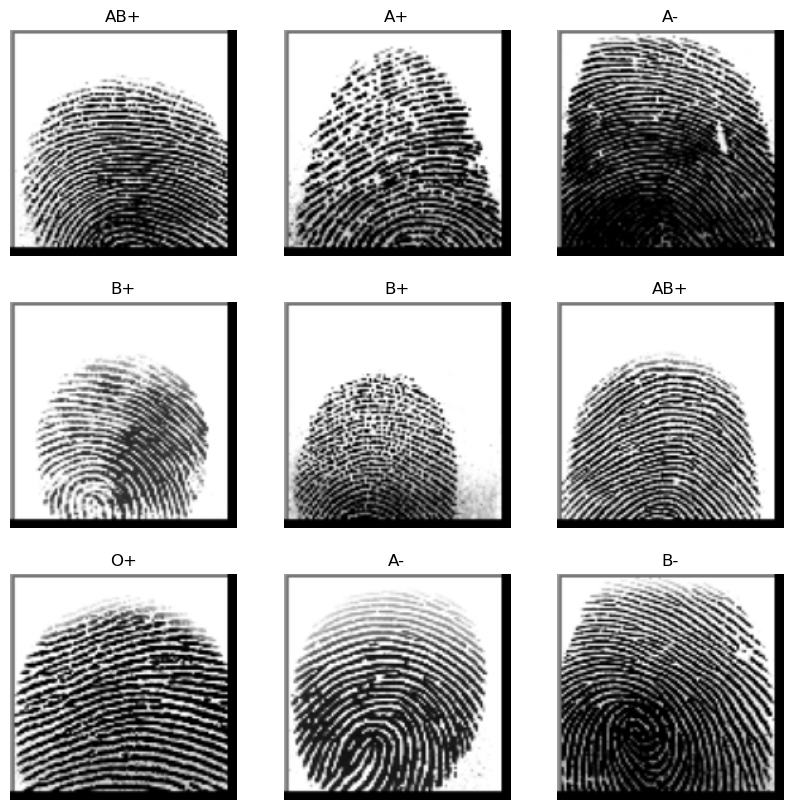

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1): # Ek batch uthao
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [5]:
import os
for folder in class_names:
    count = len(os.listdir(os.path.join(data_dir, folder)))
    print(f"Group {folder}: {count} images")

Group A+: 566 images
Group A-: 1010 images
Group AB+: 708 images
Group AB-: 761 images
Group B+: 652 images
Group B-: 741 images
Group O+: 852 images
Group O-: 712 images


In [6]:
# Ye line aapko batayegi ki kaunsa number kis folder ko mila hai
for i, name in enumerate(train_ds.class_names):
    print(f"Folder Name: {name} ---> Model Label Index: {i}")

Folder Name: A+ ---> Model Label Index: 0
Folder Name: A- ---> Model Label Index: 1
Folder Name: AB+ ---> Model Label Index: 2
Folder Name: AB- ---> Model Label Index: 3
Folder Name: B+ ---> Model Label Index: 4
Folder Name: B- ---> Model Label Index: 5
Folder Name: O+ ---> Model Label Index: 6
Folder Name: O- ---> Model Label Index: 7


In [7]:
data_augmentation = tf.keras.Sequential([
  layers.RandomRotation(0.1), # Thoda sa rotate karega
  layers.RandomZoom(0.1),     # Thoda zoom in/out
  layers.RandomTranslation(0.1, 0.1) # Thoda upar-niche shift
])

# Model build karte waqt Rescaling se pehle laga do:
model = models.Sequential([
  data_augmentation,
  layers.Rescaling(1./255, input_shape=(180, 180, 3)),
  # ... baaki layers
])

In [8]:
# Flatten layer ke baad aur Dense layer ke pehle:
layers.Flatten(),
layers.Dense(128, activation='relu'),
layers.Dropout(0.5), # 50% neurons ko randomly skip karega
layers.Dense(len(class_names), activation='softmax')

In [9]:
model = models.Sequential([
  layers.Rescaling(1./255, input_shape=(180, 180, 3)),
  layers.Conv2D(32, 3, activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(128, 3, activation='relu'), # Extra layer
  layers.MaxPooling2D(),
  layers.Dropout(0.2), # Isse overfitting kam hogi
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(len(class_names), activation='softmax')
])

In [10]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 180, 180, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 178, 178, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 89, 89, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 87, 87, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 43, 43, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 41, 41, 128)      

In [14]:
lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=0.00001
)

# training ke waqt:
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=15,
  callbacks=[lr_callback]
)

Epoch 1/15
151/151 [==============================] - 43s 282ms/step - loss: 0.0231 - accuracy: 0.9935 - val_loss: 0.2307 - val_accuracy: 0.9258 - lr: 1.0000e-05
Epoch 2/15
151/151 [==============================] - 45s 298ms/step - loss: 0.0218 - accuracy: 0.9946 - val_loss: 0.2314 - val_accuracy: 0.9308 - lr: 1.0000e-05
Epoch 3/15
151/151 [==============================] - 44s 288ms/step - loss: 0.0209 - accuracy: 0.9963 - val_loss: 0.2311 - val_accuracy: 0.9300 - lr: 1.0000e-05
Epoch 4/15
151/151 [==============================] - 44s 289ms/step - loss: 0.0196 - accuracy: 0.9973 - val_loss: 0.2336 - val_accuracy: 0.9250 - lr: 1.0000e-05
Epoch 5/15
151/151 [==============================] - 42s 278ms/step - loss: 0.0195 - accuracy: 0.9969 - val_loss: 0.2324 - val_accuracy: 0.9300 - lr: 1.0000e-05
Epoch 6/15
151/151 [==============================] - 40s 267ms/step - loss: 0.0191 - accuracy: 0.9965 - val_loss: 0.2343 - val_accuracy: 0.9308 - lr: 1.0000e-05
Epoch 7/15
151/151 [========

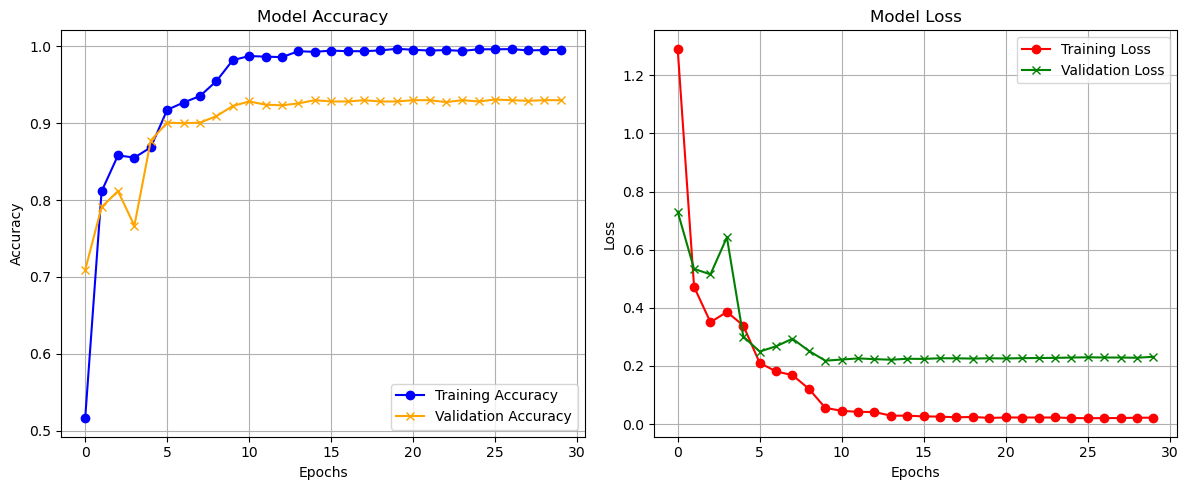

In [12]:
import matplotlib.pyplot as plt

# 1. Accuracy ka graph
plt.figure(figsize=(12, 5))

# Plot Training & Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', marker='x')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# 2. Loss ka graph
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='red', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', color='green', marker='x')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

In [13]:
model.save('blood_group_model.h5')
print("Model file 'blood_group_model.h5' save ho gayi hai!")

Model file 'blood_group_model.h5' save ho gayi hai!


/home/ai-ml/anaconda3/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [3]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import tkinter as tk
from tkinter import filedialog
import os

# --- Step 1: Model Load Karein ---
# Agar tune model save nahi kiya hai, toh training wale code ke baad 
# model.save('blood_group_model.h5') run kar lena.
# Phir ye code chalana.
model_path = 'blood_group_model.h5' 

if not os.path.exists(model_path):
    print(f"Error: Bhai, '{model_path}' file nahi mili. Pehle model save kar le!")
    exit()

model = tf.keras.models.load_model(model_path)
print("Model load ho gaya hai, bhai!")

# --- Step 2: Category Names Define Karein ---
# Dhyaan rahe ye wahi order ho jo training mein tha (alphabetical)
class_names = ['A-', 'A+', 'AB-', 'AB+', 'B-', 'B+', 'O-', 'O+']

# --- Step 3: File Upload Window ---
# Isse ek sundar si window khulegi file select karne ke liye
root = tk.Tk()
root.withdraw() # Main window chhupa do, sirf file dialog dikhao

print("\nBhai, abhi ek window khulegi, usme se fingerprint image select kar...")
file_path = filedialog.askopenfilename(
    title="Select Fingerprint Image",
    filetypes=[("Image files", "*.jpg *.jpeg *.png")]
)

# Agar user ne cancel kar diya
if not file_path:
    print("Bhai tune koi file select nahi ki. Program band ho raha hai.")
    exit()

print(f"Selected Image: {file_path}")

# --- Step 4: Image ko Model ke liye Taiyar Karein ---
img_height = 180 # Wahi size jo training mein tha
img_width = 180

# Image load aur resize
img = image.load_img(file_path, target_size=(img_height, img_width))
img_array = image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch (1, 180, 180, 3)

# Normalization (Training jaisa hi karna padega)
img_array = img_array / 255.0 

# --- Step 5: Prediction aur Result ---
print("\nModel analysis kar raha hai...")
predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0]) # Probabilities nikaalein

# Sabse zyada score wali category
predicted_class = class_names[np.argmax(score)]
confidence = 100 * np.max(score)

# Final Result Print
print("\n" + "="*40)
print(f"RESULT: Bhai, ye fingerprint '{predicted_class}' Blood Group ka hai!")
print(f"Confidence: {confidence:.2f}% (Model ko itna yakeen hai)")
print("="*40)

# Optional: Image aur result dikhane ke liye
import matplotlib.pyplot as plt
plt.imshow(img)
plt.title(f"Predicted: {predicted_class} ({confidence:.2f}%)")
plt.axis('off')
plt.show()


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/home/ai-ml/anaconda3/lib/python3.11/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/ai-ml/anaconda3/lib/python3.11/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/home/ai-ml/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/ai-ml/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/home

AttributeError: _ARRAY_API not found

ImportError: numpy.core._multiarray_umath failed to import

ImportError: numpy.core.umath failed to import

In [ ]:
import tensorflow as tf
import numpy as np
import cv2  # OpenCV use karenge preprocessing ke liye
import tkinter as tk
from tkinter import filedialog
import os
import matplotlib.pyplot as plt

# --- Step 1: Model Load Karein ---
model_path = 'blood_group_model.h5' 
if not os.path.exists(model_path):
    print(f"Error: Bhai, '{model_path}' file nahi mili. Pehle model save kar le!")
    exit()

model = tf.keras.models.load_model(model_path)
print("Model load ho gaya hai, bhai!")

# --- Step 2: Category Names ---
class_names = ['A-', 'A+', 'AB-', 'AB+', 'B-', 'B+', 'O-', 'O+']
img_height = 180
img_width = 180

# --- Step 3: File Upload ---
root = tk.Tk()
root.withdraw() 
print("\nBhai, camera se li hui fingerprint ki photo select kar...")
file_path = filedialog.askopenfilename(
    title="Select Fingerprint Image",
    filetypes=[("Image files", "*.jpg *.jpeg *.png *.BMP")]
)

if not file_path:
    print("Bhai tune koi file select nahi ki.")
    exit()

# ==========================================================
# --- Step 4: [CRITICAL] Image Preprocessing (B&W Conversion) ---
# ==========================================================
print("Camera image ko process kar raha hoon...")

# 1. Image ko color (RGB) mein load karein OpenCV se
original_img = cv2.imread(file_path)

# 2. Image ko Black and White (Grayscale) mein convert karein
gray_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)

# 3. [Extra Step] Contrast badhayein (CLAHE use karke) takki ridges saaf dikhein
# Ye step fingerprint lines ko ubhaar deta hai.
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced_img = clahe.apply(gray_img)

# 4. Resize karein model ke input size ke hisaab se
resized_img = cv2.resize(enhanced_img, (img_width, img_height))

# 5. Normalization aur Dims expand (Model ke liye taiyar)
img_array = resized_img.astype('float32') / 255.0  
img_array = np.expand_dims(img_array, axis=-1)  # Add channel dim (180, 180, 1)
img_array = np.expand_dims(img_array, axis=0)   # Add batch dim (1, 180, 180, 1)

# **IMPORTANT**: Agar aapka model 3 channels (RGB) par train hua hai,
# toh upar wale channel add karne wale steps ko skip karke 
# seedha original color image ko resize aur normalize karke bhejein.
# Lekin kyunki data B&W tha, umeed hai model single channel expect kar raha hoga.

# Agar model 3 channel chahta hai grayscale ke baad bhi (TensorFlow behavior):
if model.layers[0].input_shape[-1] == 3:
    # Single channel grayscale ko 3 channel grayscale banao (R=G=B)
    img_array = cv2.cvtColor(resized_img, cv2.COLOR_GRAY2RGB)
    img_array = img_array.astype('float32') / 255.0
    img_array = np.expand_dims(img_array, axis=0) # (1, 180, 180, 3)
# ==========================================================

# --- Step 5: Prediction ---
print("Model analysis kar raha hai...")
predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0]) 

predicted_class = class_names[np.argmax(score)]
confidence = 100 * np.max(score)

# Final Result
print("\n" + "="*40)
print(f"RESULT: Bhai, ye fingerprint '{predicted_class}' Blood Group ka hai!")
print(f"Confidence: {confidence:.2f}%")
print("="*40)

# Dikhayein kya process hua
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
plt.title("Original Camera Image")
plt.axis('off')

plt.subplot(1, 2, 2)
# model ke input array ko display ke liye wapas image format mein lao
display_img = np.squeeze(img_array) 
if len(display_img.shape) == 3: display_img = display_img[:,:,0] # if 3 channels, take first
plt.imshow(display_img, cmap='gray')
plt.title("Processed Input (What Model Sees)")
plt.axis('off')

plt.show()

Model load ho gaya hai, bhai!

Bhai, camera se li hui fingerprint ki photo select kar...
